# Self-Heal Loop with LangChain

> A repair loop is safe only when every attempt is bounded, receipt-bound, and compensated before a non-success result escapes.


## What this pattern does

Self-Heal starts with a known failure, proposes one patch at a time, reviews it, applies it, and verifies the changed workspace. A passing verification commits the repaired state. Every other terminal path compensates newest-first and reports whether the original baseline was restored.

### Learning goals

By the end, you will be able to read the repair workflow as ordinary Python inputs and outputs, identify which decisions belong to models and which belong to deterministic code, and follow the receipts that make rollback provable.

### Who owns each decision?

| Decision | Owner | Why |
|---|---|---|
| Diagnose a failure | Swappable role, optionally a model | This is an interpretive task. |
| Draft a patch | Swappable role, optionally a model | This is a generative task. |
| Review, apply, and verify | Deterministic callbacks | Safety policy and workspace evidence must not depend on model judgment. |
| Retry, stop, or roll back | Deterministic transaction core | Bounds and compensation are transaction rules. |
| Choose a terminal presentation | Deterministic status rule | Rendering must not change the result. |

### Five safety invariants

1. Every run captures its own baseline before any repair role runs.
2. Diagnose, draft, review, and verify are observationally pure: they may not mutate managed state.
3. The same `(failure.signature, patch.digest)` pair is never applied twice.
4. Apply, verification, and rollback evidence must bind to the patch or commit it describes.
5. A non-success result proves restoration or becomes human handoff.

### Two paths to keep in mind

A successful run can take more than one round:

```text
success:
failure₁ -> patch₁/c1 -> verify failure₂ -> patch₂/c2 -> verify success
```

A later regression compensates in reverse apply order:

```text
compensation:
c1 -> c2 -> regression -> rollback c2 -> rollback c1 -> baseline restored
```



## LangChain and LCEL from basic Python

If you know how an ordinary Python function accepts an argument and returns a value, you have the starting point.

- A **runnable** is an object with `.invoke(input)`.
- LCEL is LangChain's composition syntax.
- `left | right` sends the left runnable's output into the right runnable.
- `RunnableLambda` wraps an ordinary Python function as a runnable.
- `RunnableBranch` selects one runnable from deterministic conditions.
- `ChatPromptTemplate` creates chat messages from named Python inputs.
- `FakeListChatModel` returns fixed replies in call order for offline examples.

LCEL makes the outer composition smaller, but it leaves the transaction internals inside one named runnable. The matrix and walkthroughs later in the notebook make those otherwise opaque transaction outcomes inspectable.

| | [`langgraph/`](../langgraph/tutorial.ipynb) (`StateGraph`) | `langchain/` (LCEL) |
|---|---|---|
| Repair stages | Explicit graph nodes and conditional edges | Runnable model roles around one named transaction |
| Deterministic roles | Plain callables from `new_runtime()` | Exact fake replies converted by runnable adapters |
| Business bound | `StabilityPolicy.max_rounds` | The same policy inside the sealed `SelfHealLoop` |
| Safety proof | Apply, verify, rollback receipts plus state digests | The same normalized `HealTrace` record |
| Trade-off | More code, every transition is inspectable | Smaller composition, transaction internals stay in Python |


## Setup

The deterministic section is fully offline. The setup searches upward for the pattern helpers and repository helpers, so execution works from the repository root, the notebook directory, `nbmake`, or JupyterLab without relying on `__file__` or a brittle relative path.


In [1]:
from __future__ import annotations

import html
import json
import sys
from pathlib import Path

# Find each helper's nearest ancestor so execution works from Jupyter,
# nbmake, or the repository root without relying on __file__.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / _marker).exists()
    )
    sys.path.insert(0, str(_dir))

# Framework imports intentionally follow path setup; E402 marks that order.
from IPython.display import HTML, display  # noqa: E402
from IPython.utils.capture import capture_output  # noqa: E402
from langchain_core.language_models.fake_chat_models import (  # noqa: E402
    FakeListChatModel,
)
from langchain_core.output_parsers import StrOutputParser  # noqa: E402
from langchain_core.prompts import ChatPromptTemplate  # noqa: E402
from langchain_core.runnables import RunnableBranch, RunnableLambda  # noqa: E402
from pydantic import BaseModel, ConfigDict, Field  # noqa: E402

# Local imports group model configuration, the sealed core, and shared fixtures.
from model_config import get_model  # noqa: E402
from nbtools import show_graph  # noqa: E402
from pattern import FailureSignal, HealStatus, Patch, SelfHealLoop  # noqa: E402
from shared import (  # noqa: E402
    RECORD_FIELDS,
    SCENARIO_ORDER,
    assert_expected_record,
    format_scenario_matrix,
    format_scenario_walkthrough,
    new_runtime,
    parse_diagnosis_json,
    parse_patch_json,
    run_core_reference,
    trace_record,
)

## LCEL pipeline

We first build two small model-role pipes: one diagnoses a failure and one drafts a patch. Both feed a single bounded transaction runnable. A terminal branch then normalizes the completed trace into the same public record regardless of status.

The offline fixtures use exact JSON strings; the optional real-model path uses provider-native structured output. Both paths cross the same strict shared parsers before reaching mutation authority.

### Prompts

A `ChatPromptTemplate` fills named placeholders from an input dictionary and produces chat messages. These prompts ask for diagnosis and patch content only; they do not approve, apply, verify, or roll back anything.


In [2]:
# Named inputs become messages here; prompt text grants no policy authority.
diagnose_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Diagnose the failure. Return only JSON with key diagnosis."),
        ("human", "kind={kind}\ncode={code}\nerror={error_text}\nfiles={affected_files}"),
    ]
)
# The diagnosis string from the first pipe fills this template's only slot.
draft_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Draft one patch. Return only JSON with description, payload, and touches.",
        ),
        ("human", "diagnosis={diagnosis}"),
    ]
)


### Output schemas

The optional provider path asks for these exact Pydantic shapes. Shape validation reduces ambiguity, but it does not replace the repository's stricter patch rules.


In [3]:
# Pydantic checks response shape and rejects undeclared fields here.
# It does not decide whether a patch is safe to apply.
class DiagnosisOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    diagnosis: str = Field(
        min_length=1,
        description="One concise diagnosis of the deterministic failure",
    )


# This nested set object matches the canonical payload shape used by the core.
class PatchPayload(BaseModel):
    model_config = ConfigDict(extra="forbid")

    set: dict[str, str] = Field(
        min_length=1,
        description="Nonempty map of canonical relative paths to replacement text",
    )


# The shared parser later requires touches to match the payload keys exactly.
class PatchOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    description: str = Field(min_length=1, description="Patch intent")
    payload: PatchPayload = Field(
        description='Structured payload containing exactly one "set" object',
    )
    touches: list[str] = Field(
        min_length=1,
        description="Canonical relative POSIX paths matching payload keys exactly",
    )

### Strict structured adapters

**Input:** A provider adapter result containing `parsed` data or a parsing error.

**Purpose:** Reduce provider output to the same strict diagnosis and patch types used by the offline path.

**Invariant:** Provider-controlled parser details and invalid field values never cross this schema-only boundary.

**Failure route:** The adapter raises a stable schema-only error; the sealed transaction records it as a stage error and compensates if needed.

Native structured output constrains the response shape. The strict shared parsers still enforce nonblank diagnosis text, canonical patch JSON, safe paths, and exact agreement between payload paths and `touches`.


In [4]:
# Invariant: provider-controlled errors never cross this schema-only boundary.
# include_raw=True yields raw, parsed, and parsing_error fields; only the
# parsed Pydantic value is allowed beyond this helper.
def _parsed_structured(result: dict[str, object], schema):
    parsing_error = result.get("parsing_error")
    if parsing_error is not None:
        raise ValueError(f"{schema.__name__} structured parsing failed")
    parsed = result.get("parsed")
    if not isinstance(parsed, schema):
        raise TypeError(f"expected parsed {schema.__name__}")
    return parsed


# Both adapters reuse the shared strict parsers, so offline and live values
# receive the same domain checks.
def parse_structured_diagnosis(result: dict[str, object]) -> str:
    parsed = _parsed_structured(result, DiagnosisOutput)
    try:
        return parse_diagnosis_json(parsed.model_dump_json())
    except (TypeError, ValueError):
        raise ValueError("DiagnosisOutput strict validation failed") from None


def parse_structured_patch(result: dict[str, object]) -> Patch:
    parsed = _parsed_structured(result, PatchOutput)
    # Rebuild canonical JSON from parsed fields; ignore the raw provider response.
    payload = json.dumps(
        {"set": parsed.payload.set},
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    raw = json.dumps(
        {
            "description": parsed.description,
            "payload": payload,
            "touches": parsed.touches,
        },
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    try:
        return parse_patch_json(raw)
    except (TypeError, ValueError):
        raise ValueError("PatchOutput strict validation failed") from None

### Bind schemas to a live model

`with_structured_output(..., method="json_schema", include_raw=True)` asks the provider to return schema-bound values. Raw responses remain transient; only parsed, strictly validated values may enter the transaction.


In [5]:
def build_structured_role_models(model):
    # Schema binding constrains response shape; it grants no transaction authority.
    # include_raw=True supplies the envelope consumed by _parsed_structured.
    return (
        model.with_structured_output(
            DiagnosisOutput, method="json_schema", include_raw=True
        ),
        model.with_structured_output(
            PatchOutput, method="json_schema", include_raw=True
        ),
    )

### Build diagnosis and drafting pipes

`|` is evaluated left to right. The prompt creates messages, the model returns a response, and the final parser runnable converts that response into a plain Python `str` or `Patch`.

The offline builder parses text from `FakeListChatModel`. The live builder starts from provider-native structured output. Neither builder receives mutation authority.


In [6]:
# Invariant: role pipes produce proposals only; deterministic callbacks
# retain all transaction authority.
def build_role_pipes(model):
    # diagnose: input dictionary -> chat messages -> model text -> Python string.
    diagnose_pipe = diagnose_prompt | model | StrOutputParser() | RunnableLambda(
        parse_diagnosis_json
    )
    # draft: diagnosis dictionary -> chat messages -> model text -> Patch.
    draft_pipe = draft_prompt | model | StrOutputParser() | RunnableLambda(
        parse_patch_json
    )
    return diagnose_pipe, draft_pipe


def build_structured_role_pipes(model):
    diagnosis_model, patch_model = build_structured_role_models(model)
    # Structured pipes replace model text with a validated Pydantic envelope,
    # then return the same Python domain values as the offline pipes.
    diagnose_pipe = diagnose_prompt | diagnosis_model | RunnableLambda(
        parse_structured_diagnosis
    )
    draft_pipe = draft_prompt | patch_model | RunnableLambda(
        parse_structured_patch
    )
    return diagnose_pipe, draft_pipe

### Convert a failure into prompt inputs

The transaction works with an immutable `FailureSignal`. This adapter exposes only its named fields as the dictionary expected by `diagnose_prompt`.


In [7]:
def failure_input(failure: FailureSignal) -> dict[str, object]:
    return {
        "kind": failure.kind,
        "code": failure.code,
        "error_text": failure.error_text,
        "affected_files": list(failure.affected_files),
    }

### Build an exact offline fake

`FakeListChatModel` returns its list entries in call order. Each scenario therefore interleaves one diagnosis reply and one patch reply per planned round. The transaction later asserts the exact diagnose/draft counts and the total response count, so a missing, extra, or cycled call fails visibly.


In [8]:
# Invariant: responses follow the sealed loop's diagnose-then-draft call order exactly.
def fake_model_for(spec) -> FakeListChatModel:
    # A new reply list gives each scenario its own isolated model state.
    responses: list[str] = []
    for diagnosis, patch_plan in zip(spec.diagnoses, spec.patches, strict=True):
        patch = patch_plan.patch()
        responses.extend(
            [
                json.dumps(
                    {"diagnosis": diagnosis},
                    sort_keys=True,
                    separators=(",", ":"),
                ),
                json.dumps(
                    {
                        "description": patch.description,
                        "payload": patch.payload,
                        "touches": list(patch.touches),
                    },
                    sort_keys=True,
                    separators=(",", ":"),
                ),
            ]
        )
    # The fake still traverses the real prompt, parser, and runnable composition.
    return FakeListChatModel(responses=responses)

### Normalize one terminal trace

**Input:** A completed scenario name and `HealTrace`.

**Purpose:** Produce and validate the ten-field public record.

**Invariant:** Rendering is observational only; it cannot change transaction state or terminal status.

**Failure route:** A malformed public record fails its assertion instead of being displayed as valid evidence.

The function returns the record without printing it. Default notebook output stays compact; `show_record(name)` later provides deliberate access to one full record.


In [9]:
def render_record(item: dict[str, object]) -> dict[str, object]:
    # Read the completed trace only; this renderer cannot change the workspace.
    record = trace_record(item["scenario"], item["trace"])
    # Reject malformed evidence before the caller stores or displays the record.
    assert_expected_record(record)
    return record

### Run one bounded transaction

**Input:** One fresh scenario runtime and one model runnable.

**Purpose:** Adapt the two model roles, construct a fresh sealed `SelfHealLoop`, and execute exactly one repair transaction.

**Invariant:** `build_role_pipes(model)` runs once per transaction, model roles remain observational, and fake calls exactly match the interleaved response list.

**Failure route:** The sealed core records role, policy, mutation, verification, and compensation failures in its terminal trace.

The transaction remains one runnable because `SelfHealLoop` already owns the hardened round logic, receipt checks, decision precedence, and compensation. Reimplementing those internals as a second framework-specific loop would create another safety authority.


In [10]:
# Build each role pipe once; the sealed core retains mutation
# and retry authority.
def invoke_transaction(inputs: dict[str, object]) -> dict[str, object]:
    runtime = inputs["runtime"]
    model = inputs["model"]
    diagnose_pipe, draft_pipe = build_role_pipes(model)
    role_counts = {"diagnose": 0, "draft": 0}

    # These callbacks adapt the core's Python values to the two LCEL input shapes.
    def diagnose(failure: FailureSignal) -> str:
        role_counts["diagnose"] += 1
        return diagnose_pipe.invoke(failure_input(failure))

    def draft(diagnosis: str) -> Patch:
        role_counts["draft"] += 1
        return draft_pipe.invoke({"diagnosis": diagnosis})

    # LCEL supplies proposals; the loop owns review, apply, verify, bounds,
    # receipt checks, and compensation.
    loop = SelfHealLoop(
        diagnose=diagnose,
        fix=draft,
        review=runtime.review,
        apply=runtime.workspace.apply,
        verify=runtime.verify,
        rollback=runtime.workspace.rollback,
        state_digest=runtime.workspace.state_digest,
        stability=runtime.scenario.stability,
    )
    trace = loop.heal(runtime.scenario.initial_failure)
    # Offline only: prove that every planned fake reply was consumed exactly once.
    if isinstance(model, FakeListChatModel):
        assert role_counts == {
            "diagnose": len(runtime.scenario.diagnoses),
            "draft": len(runtime.scenario.patches),
        }
        assert sum(role_counts.values()) == len(model.responses)
    return {"scenario": runtime.scenario.name, "trace": trace}

### Name the transaction runnable

`RunnableLambda` gives the ordinary `invoke_transaction` function a runnable interface and a useful graph label.

There is deliberately no whole-transaction retry. Replaying a completed or partially compensated transaction could repeat model calls, duplicate mutation, and invalidate receipt evidence.


In [11]:
# Do not retry this whole runnable: replay could duplicate mutation.
bounded_self_heal_transaction = RunnableLambda(
    invoke_transaction,
    name="bounded_self_heal_transaction",
)


### Build terminal renderers

Each terminal class uses the same record normalizer. Separate runnable names make the selected terminal route visible without giving presentation code authority over the trace.


In [12]:
# Different names expose the selected terminal route; all three stay read-only.
render_fixed = RunnableLambda(render_record, name="render_fixed")
render_compensated = RunnableLambda(render_record, name="render_compensated")
render_handoff = RunnableLambda(render_record, name="render_handoff")


### Select the terminal renderer

**Input:** The already-completed transaction trace.

**Purpose:** Route fixed, compensated, and human-handoff outcomes to a named renderer.

**Invariant:** Conditions inspect terminal status only; the branch does not retry or mutate.

**Failure route:** Statuses not classified as fixed or handoff take the compensated renderer, matching the existing presentation contract.


In [13]:
# Keep every human-handoff terminal status in one explicit routing set.
handoff_statuses = {
    HealStatus.MAX_ROUNDS_HUMAN_HANDOFF,
    HealStatus.STAGE_ERROR_HUMAN_HANDOFF,
    HealStatus.ROLLBACK_FAILED_HUMAN_HANDOFF,
}
# Conditions run in order; the last renderer is the default.
# Each renderer reads the completed trace and cannot change its status.
terminal_branch = RunnableBranch(
    (lambda item: item["trace"].status is HealStatus.FIXED, render_fixed),
    (lambda item: item["trace"].status in handoff_statuses, render_handoff),
    render_compensated,
)


### Assemble and inspect the pipeline

The complete outer flow is intentionally small: run one bounded transaction, then choose a renderer. The runnable graph shows that boundary while the scenario walkthroughs expose the transaction's internal receipt sequence.


In [14]:
self_heal_chain = bounded_self_heal_transaction | terminal_branch


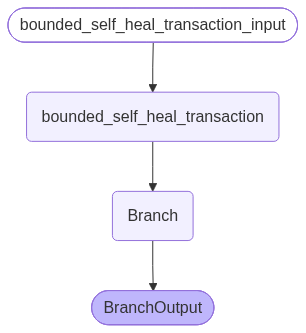

In [15]:
LANGCHAIN_GRAPH_ALT = (
    "Self-Heal LCEL model roles, transaction boundary, and terminal branch"
)
# Capture the generated graph first so the final image can carry useful alt text.
with capture_output() as _graph_capture:
    show_graph(self_heal_chain, alt=LANGCHAIN_GRAPH_ALT)
# show_graph emits display data; select its PNG payload for the HTML image.
_graph_png = next(
    output.data["image/png"]
    for output in _graph_capture.outputs
    if "image/png" in output.data
)
display(
    HTML(
        f'<img alt="{html.escape(LANGCHAIN_GRAPH_ALT)}" '
        f'src="data:image/png;base64,{_graph_png}" />'
    )
)


## Deterministic scenarios

Each run gets a fresh runtime and a fake whose replies are the exact diagnosis/patch pairs for that scenario. The LCEL chain validates the locked record, then compares its complete ten-field result with another fresh runtime executed by the sealed `SelfHealLoop` core.

The notebook prints only a compact matrix. Complete records remain in `langchain_records`, and `show_record(name)` is available when you intentionally want one public record while debugging.


In [16]:
# Give every scenario a fresh workspace and fake so state and replies cannot leak.
langchain_records = []
for scenario_name in SCENARIO_ORDER:
    runtime = new_runtime(scenario_name)
    model = fake_model_for(runtime.scenario)
    record = self_heal_chain.invoke({"runtime": runtime, "model": model})
    assert_expected_record(record)
    # Compare the LCEL result with a second fresh core run, field for field.
    core_trace, _core_runtime = run_core_reference(scenario_name)
    core_record = trace_record(scenario_name, core_trace)
    assert record == core_record
    langchain_records.append(record)

# Lock canonical row order and all ten field names before showing summaries.
assert [record["scenario"] for record in langchain_records] == list(SCENARIO_ORDER)
assert RECORD_FIELDS == (
    "scenario",
    "status",
    "stop_reason",
    "baseline_digest",
    "final_digest",
    "baseline_restored",
    "apply_receipts",
    "verification_receipts",
    "rollback_receipts",
    "stage_errors",
)
for record in langchain_records:
    assert tuple(record) == RECORD_FIELDS
    assert_expected_record(record)


# Full records stay in memory; lookup and printing are opt-in debugging aids.
def _record_named(scenario_name: str) -> dict[str, object]:
    try:
        return next(
            record
            for record in langchain_records
            if record["scenario"] == scenario_name
        )
    except StopIteration:
        raise ValueError(f"unknown executed scenario: {scenario_name}") from None


def show_record(scenario_name: str) -> None:
    """Opt in to one complete public record when debugging."""
    print(
        json.dumps(
            _record_named(scenario_name),
            ensure_ascii=False,
            indent=2,
            sort_keys=True,
        )
    )


# Default output is one bounded matrix of the key outcomes.
print(format_scenario_matrix(langchain_records))


scenario          status                         apply  verify  rollback     restored  reason
----------------  -----------------------------  -----  ------  -----------  --------  ----------------------------------
convergence       fixed                          2      2       -            -         verification_passed
critic_block      blocked_by_critic              1      1       c1           yes       review_rejected
no_progress       rolled_back_no_progress        1      1       c1           yes       no_progress_same_failure_and_patch
regression        rolled_back_regression         2      2       c2 -> c1     yes       blast_radius_exceeded
round_budget      max_rounds_human_handoff       2      2       c2 -> c1     yes       round_budget_exhausted
stage_error       stage_error_human_handoff      1      0       c1           yes       stage_error:verify
rollback_failure  rollback_failed_human_handoff  1      1       c1 (failed)  no        review_rejected


### What the matrix proves

- Convergence is the only scenario that leaves repaired state committed.
- Five of the six non-success scenarios prove restoration of the baseline.
- Rollback failure becomes human handoff because restoration cannot be proven.


### Walkthrough: convergence

Follow the two apply and verification receipts to see a second-round repair become the only committed success.


In [17]:
print(format_scenario_walkthrough(_record_named("convergence")))

scenario: convergence
outcome: fixed (verification_passed)
round 1: apply c1 patch dda1f6b5; verification failed e7e8a9de
round 2: apply c2 patch f3926b7d; verification passed
baseline restored: -


### Walkthrough: no progress

The second round repeats the same failure-and-patch pair, so the duplicate guard stops before another apply and compensation restores the baseline.


In [18]:
print(format_scenario_walkthrough(_record_named("no_progress")))

scenario: no_progress
outcome: rolled_back_no_progress (no_progress_same_failure_and_patch)
round 1: apply c1 patch 7bbc2763; verification failed 1e0be10a
rollback c1: succeeded
baseline restored: yes


### Walkthrough: rollback failure

The repair does not converge, and one failed rollback receipt means restoration cannot be proved.


In [19]:
print(format_scenario_walkthrough(_record_named("rollback_failure")))

scenario: rollback_failure
outcome: rollback_failed_human_handoff (review_rejected)
round 1: apply c1 patch bd0a4ab7; verification failed c924ae82
rollback c1: failed
baseline restored: no


In [20]:
print(
    f"{len(langchain_records)} scenarios matched the sealed core "
    f"across all {len(RECORD_FIELDS)} public fields"
)


7 scenarios matched the sealed core across all 10 public fields


## Optional real model

Only diagnosis and patch drafting cross the model boundary. Native structured output constrains response shape, while strict parsing enforces canonical content and safe paths. Deterministic review remains authoritative, and this demonstration never applies the candidate.

`get_model()` returns `None` and prints one skip line when the configured provider has no API key. On a live run, only clipped diagnosis, patch, and review summaries are displayed; raw provider messages remain transient.


In [21]:
# A missing provider key returns None, so offline execution skips this block.
model = get_model()

if model is not None:
    # Only diagnosis and drafting cross the live boundary; no transaction is run.
    diagnose_pipe, draft_pipe = build_structured_role_pipes(model)
    # Use a fresh fixture and save its digest before invoking either model role.
    candidate_runtime = new_runtime("convergence")
    failure = candidate_runtime.scenario.initial_failure
    baseline_digest = candidate_runtime.workspace.state_digest()
    diagnosis = diagnose_pipe.invoke(failure_input(failure))
    candidate_patch = draft_pipe.invoke({"diagnosis": diagnosis})
    # Reject out-of-workspace paths, then review without applying the proposal.
    # The unchanged digest proves the live model did not mutate the fixture.
    if not set(candidate_patch.touches).issubset(candidate_runtime.workspace.files):
        raise ValueError("model patch touches files outside the fresh workspace")
    candidate_review = candidate_runtime.review(candidate_patch, failure)
    assert candidate_review.patch_digest == candidate_patch.digest
    assert candidate_runtime.workspace.state_digest() == baseline_digest

    # Normalize and clip parsed summaries so model text cannot flood saved artifacts.
    def _clip_summary(value: object, limit: int = 160) -> str:
        text = " ".join(str(value).split())
        return text if len(text) <= limit else f"{text[: limit - 3]}..."


    print(f"diagnosis: {_clip_summary(diagnosis)}")
    print(
        "patch: "
        + _clip_summary(
            f"{candidate_patch.description}; files={list(candidate_patch.touches)}"
        )
    )
    decision = "approved" if candidate_review.approved else "rejected"
    print(f"review: {decision}; applied: no")


Model: ernie:glm-5.1


diagnosis: CONVERGENCE_1 indicates a numerical convergence failure in app.py. The scenario test expects an iterative algorithm (e.g., solver, optimizer, or simulation l...
patch: Fix convergence failure in app.py: correct the sign in the iterative update rule. The update step was using addition instead of subtraction (e.g., `x = x + d...
review: rejected; applied: no


## What to remember

- Self-Heal is a bounded transaction, not an open-ended autonomous retry loop.
- Models may diagnose and draft; deterministic callbacks own review, mutation, verification, rollback, and status.
- LCEL makes the outer composition small, while the sealed `SelfHealLoop` keeps transaction internals and receipt rules in one named runnable.
- Native structured output constrains shape; strict parsing and deterministic review still decide whether a candidate is acceptable.
- Exact fake-response accounting makes a missing, extra, or cycled model reply fail visibly.
- Restoration is a proof: every known apply must have a valid rollback receipt and the final digest must equal the baseline.
- The seven executed LCEL records match fresh sealed-core records across all ten public fields.


## Further reading

- [LangGraph tutorial](../langgraph/tutorial.ipynb) — the same transaction contract expressed with explicit graph stages
- [Pattern README](../README.md) — design rationale and framework-neutral public contract
- [Reference implementation guide](../../../REFERENCE_IMPL.md) — repository conventions and verification commands
- [LangChain Expression Language](https://python.langchain.com/docs/concepts/lcel/) — runnable composition concepts
